## How to represent text for AI


In [1]:
import numpy as np

def one_hot_encoding(sentence):
    words = sentence.lower().split()
    vocab = sorted(set(words))
    words_to_index = {word: idx for idx, word in enumerate(vocab)}
    one_hot_matrix = np.zeros((len(words), len(vocab)), dtype=int)
    for i, word in enumerate(words):
        one_hot_matrix[i, words_to_index[word]] = 1

    return one_hot_matrix, vocab

sentence = "I want to go to Berkeley this summer"
one_hot_matrix, voc = one_hot_encoding(sentence)
print("Vocabulary:", voc)
print("One-hot encoded matrix:\n", one_hot_matrix)

Vocabulary: ['berkeley', 'go', 'i', 'summer', 'this', 'to', 'want']
One-hot encoded matrix:
 [[0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0]]


In [2]:
def bag_of_words(sentences):
    tokenized_sentences = [sentence.lower().split() for sentence in sentences]
    flat_words = [word for sentence in tokenized_sentences for word in sentence]
    vocab = sorted(set(flat_words))
    words_to_index = {word: idx for idx, word in enumerate(vocab)}
    bow_matrix = np.zeros((len(sentences), len(vocab)), dtype=int)
    for i, sentence in enumerate(tokenized_sentences):
        for word in sentence:
            if word in words_to_index:
                bow_matrix[i, words_to_index[word]] += 1
    return bow_matrix, vocab

corpus = ["I'm not confident about my knowledge of machine learning.",
          "I want to learn more about deep learning and neural networks.",
            "I have some experience with data science but want to improve."]

bow_matrix, vocab = bag_of_words(corpus)
print("Vocabulary:", vocab)
print("Bag-of-Words matrix:\n", bow_matrix)

Vocabulary: ['about', 'and', 'but', 'confident', 'data', 'deep', 'experience', 'have', 'i', "i'm", 'improve.', 'knowledge', 'learn', 'learning', 'learning.', 'machine', 'more', 'my', 'networks.', 'neural', 'not', 'of', 'science', 'some', 'to', 'want', 'with']
Bag-of-Words matrix:
 [[1 0 0 1 0 0 0 0 0 1 0 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0]
 [1 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 0]
 [0 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]]


In [3]:
def compute_tf(sentences):
    vocab = sorted(set(word for sentence in sentences for word in sentence.lower().split()))
    words_to_index = {word: idx for idx, word in enumerate(vocab)}
    tf_matrix = np.zeros((len(sentences), len(vocab)), dtype=np.float32)
    for i, sentence in enumerate(sentences):
        words = sentence.lower().split()
        word_count = len(words)
        for word in words:
            if word in words_to_index:
                tf_matrix[i, words_to_index[word]] += 1 / word_count

    return tf_matrix, vocab

def compute_idf(sentences, voc):
    num_docs = len(sentences)
    idf_vector = np.zeros(len(voc), dtype=np.float32)
    words_index = {word: idx for idx, word in enumerate(voc)}
    for word in voc:
        df = sum(1 for sentence in sentences if word in sentence.lower().split())
        idf_vector[words_index[word]] = np.log(num_docs / (df + 1)) + 1

    return idf_vector

def compute_tfidf(sentences):
    tf_matrix, vocab = compute_tf(sentences)
    idf_vector = compute_idf(sentences, vocab)
    tfidf_matrix = tf_matrix * idf_vector
    return tfidf_matrix, vocab

tfidf_matrix, vocab = compute_tfidf(corpus)
print("Vocabulary:", vocab)
print("TF-IDF matrix:\n", tfidf_matrix)
      

Vocabulary: ['about', 'and', 'but', 'confident', 'data', 'deep', 'experience', 'have', 'i', "i'm", 'improve.', 'knowledge', 'learn', 'learning', 'learning.', 'machine', 'more', 'my', 'networks.', 'neural', 'not', 'of', 'science', 'some', 'to', 'want', 'with']
TF-IDF matrix:
 [[0.11111111 0.         0.         0.1561628  0.         0.
  0.         0.         0.         0.1561628  0.         0.1561628
  0.         0.         0.1561628  0.1561628  0.         0.1561628
  0.         0.         0.1561628  0.1561628  0.         0.
  0.         0.         0.        ]
 [0.09090909 0.12776956 0.         0.         0.         0.12776956
  0.         0.         0.09090909 0.         0.         0.
  0.12776956 0.12776956 0.         0.         0.12776956 0.
  0.12776956 0.12776956 0.         0.         0.         0.
  0.09090909 0.09090909 0.        ]
 [0.         0.         0.12776956 0.         0.12776956 0.
  0.12776956 0.12776956 0.09090909 0.         0.12776956 0.
  0.         0.         0.    

## Embedding, application and representation

In [6]:
!pip install gensim
!pip install adjustText
!pip install umap-learn

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 25.4 MB/s eta 0:00:01
   ------ --------------------------------- 4.2/24.4 MB 12.6 MB/s eta 0:00:02
   ------------- -------------------------- 8.4/24.4 MB 17.3 MB/s eta 0:00:01
   ----------------- ---------------------- 10.5/24.4 MB 15.2 MB/s eta 0:00:01
   --------------------- ------------------ 13.1/24.4 MB 13.3 MB/s eta 0:00:01
   -------------------------- ------------- 16.0/24.4 MB 13.4 MB/s eta 0:00:01
   -------------------------------- ------- 19.9/24.4 MB 14.8 MB/s eta 0:00:01
   ------------------------------------ --- 22.3/24.4 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 12.9 MB/s  0:00:01


   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ----------------------------- ---------- 9.7/13.1 MB 46.5 MB/s eta 0:00:01
   ---------------------------------------  12.8/13.1 MB 47.3 MB/s eta 0:00:01
   ---------------------------------------- 13.1/13.1 MB 28.3 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 2.4.3

   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
    Uninstalling numpy-2.4.3:
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
      Successfully uninstalled numpy-2.4.3
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.3.0 requires dill<0.4.1,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.3.0 requires fsspec[http]<=2025.9.0,>=2023.1.0, but you have fsspec 2026.2.0 which is incompatible.
datasets 4.3.0 requires multiprocess<0.70.17, but you have multiprocess 0.70.19 which is incompatible.
llama-index-legacy 0.9.48.post4 requires tenacity<9.0.0,>=8.2.0, but you have tenacity 9.1.4 which is incompatible.
llama-index-multi-modal-llms-openai 0.1.9 requires llama-index-core<0.11.0,>=0.10.1, but you have llama-index-core 0.14.18 which is incompatible.
llama-index-multi-modal-llms-openai 0.1.9 requires llama-index-llms-openai<0.2.0,>=0.1.1, but you have llama-index-llms-openai 0.6.26 which is incompatible.
llama-index-program-openai 

In [16]:
!pip install --upgrade numpy==2.3.0 numba umap-learn

Found existing installation: numba 0.65.0
Uninstalling numba-0.65.0:
  Successfully uninstalled numba-0.65.0
Found existing installation: llvmlite 0.47.0
Uninstalling llvmlite-0.47.0:
  Successfully uninstalled llvmlite-0.47.0


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


Found existing installation: numba 0.65.0
Uninstalling numba-0.65.0:
  Successfully uninstalled numba-0.65.0
Found existing installation: llvmlite 0.47.0
Uninstalling llvmlite-0.47.0:
  Successfully uninstalled llvmlite-0.47.0


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.9 MB 11.8 MB/s eta 0:00:01
   ------------- -------------------------- 4.2/12.9 MB 11.5 MB/s eta 0:00:01
   ------------------- -------------------- 6.3/12.9 MB 10.4 MB/s eta 0:00:01
   -------------------------- ------------- 8.4/12.9 MB 10.0 MB/s eta 0:00:01
   ----------------------------- ---------- 9.4/12.9 MB 10.0 MB/s eta 0:00:01
   ------------------------------------ --- 11.8/12.9 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 9.3 MB/s  0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.0
    Uninstalling numpy-2.3.0:
      Successfully uninstalled numpy-2.3.0


...

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.9 MB 11.8 MB/s eta 0:00:01
   ------------- -------------------------- 4.2/12.9 MB 11.5 MB/s eta 0:00:01
   ------------------- -------------------- 6.3/12.9 MB 10.4 MB/s eta 0:00:01
   -------------------------- ------------- 8.4/12.9 MB 10.0 MB/s eta 0:00:01
   ----------------------------- ---------- 9.4/12.9 MB 10.0 MB/s eta 0:00:01
   ------------------------------------ --- 11.8/12.9 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 9.3 MB/s  0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.0
    Uninstalling numpy-2.3.0:
      Successfully uninstalled numpy-2.3.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
librosa 0.11.0 requires numba>=0.51.0, which is not installed.
umap-learn 0.5.12 requires numba>=0.51.2, which is not installed.
datasets 4.3.0 requires dill<0.4.1,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.3.0 requires fsspec[http]<=2025.9.0,>=2023.1.0, but you have fsspec 2026.2.0 which is incompatible.
datasets 4.3.0 requires multiprocess<0.70.17, but you have multiprocess 0.70.19 which is incompatible.
llama-index-legacy 0.9.48.post4 requires tenacity<9.0.0,>=8.2.0, but you have tenacity 9.1.4 which is incompatible.
llama-index-multi-modal-llms-openai 0.1.9 requires llama-index-core<0.11.0,>=0.10.1, but you have llama-index-core 0.14.18 which is incompatible.
llama-index-multi-modal-llms-openai 0.1.9 requires llama-index-llms-openai<0.2.0,>=0.1.1, but you have llama-index-llms-openai 0.

INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.

The conflict is caused by:
    The user requested llvmlite==0.42.0
    numba 0.60.0 depends on llvmlite<0.44 and >=0.43.0dev0

Additionally, some packages in these conflicts have no matching distributions available for your environment:
    llvmlite

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict



ERROR: Cannot install llvmlite==0.42.0 and numba==0.60.0 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


  Using cached numba-0.65.0-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl.metadata (4.9 kB)
Using cached numba-0.65.0-cp311-cp311-win_amd64.whl (2.7 MB)
Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl (38.1 MB)

   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   -------------------- ------------------- 1/2 [numba]
   ------------------

In [4]:
import numpy as np
import pandas as pd
import os
import re
import time
import nltk
from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from adjustText import adjust_text 
from umap import UMAP


ImportError: DLL load failed while importing _dynfunc: An Application Control policy has blocked this file.

In [5]:

import urllib.request
import zipfile
import os

# Download IMDB dataset
url = "https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true"
zip_path = "IMDB.zip"

print("Downloading IMDB dataset...")
urllib.request.urlretrieve(url, zip_path)
print("Download complete!")

# Extract the zip file
print("Extracting files...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")
print("Extraction complete!")

# List extracted files
extracted_files = os.listdir(".")
print("Extracted files:", [f for f in extracted_files if f.endswith('.csv')])

df = pd.read_csv("IMDB Dataset.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Download complete!
Extracting files...
Extraction complete!
Extracted files: ['IMDB Dataset.csv']
Dataset loaded: 50000 rows, 2 columns


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
def preprocessing_reviews(reviews):

    """
    simple preprocessing: splitting on the space and remove word less than 1 chr
    """

    processed_reviews = []

    for review in tqdm(reviews):
        review = re.sub('<[^>]+>', '', review)
        processed = re.sub('[^a-zA-Z ]', '', review)
        words = processed.split()
        processed_reviews.append(' '.join([word.lower() for word in words if len(word) > 1]))
    return processed_reviews

df['reviews_processed'] = preprocessing_reviews(df['review'])
df['tokens'] = df['reviews_processed'].apply(nltk.word_tokenize)
df.head()

  0%|          | 0/50000 [00:00<?, ?it/s]

100%|██████████| 50000/50000 [00:02<00:00, 20623.69it/s]


,review,sentiment,reviews_processed,tokens
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,positive,wonderful little production the filming techni...,"[wonderful, little, production, the, filming, ..."
2,I thought this was a wonderful way to spend ti...,positive,thought this was wonderful way to spend time o...,"[thought, this, was, wonderful, way, to, spend..."
3,Basically there's a family where a little boy ...,negative,basically theres family where little boy jake ...,"[basically, theres, family, where, little, boy..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is vi...,"[petter, matteis, love, in, the, time, of, mon..."


In [7]:

# Download required NLTK data
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
print("NLTK data downloaded successfully!")


NLTK data downloaded successfully!


In [8]:
start_time = time.time()
# embedding
model = Word2Vec(sentences=df['tokens'].tolist(),
                 sg=1,
                 vector_size=100,
                 window=5,
                 workers=4)

print(f'Time needed : {(time.time() - start_time) / 60:.2f} mins')

Time needed : 1.37 mins


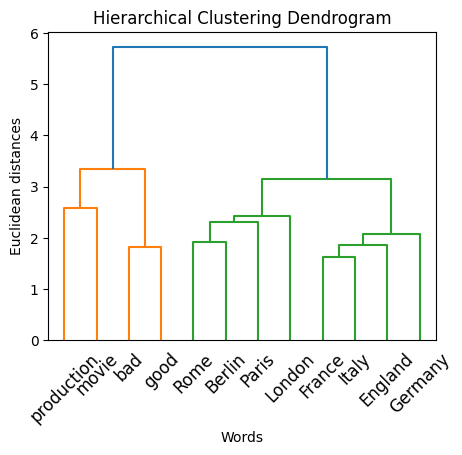

In [9]:
# Entire set of words in the model
all_words = list(model.wv.index_to_key)  
all_vectors = np.array([model.wv[word] for word in all_words])

# Highlighted words and their vectors
highlight_words = ['Berlin', 'Paris', 'London','Rome', 'Italy',
                   'France', 'Germany', 'England', 'movie', 'production', 'good', 'bad']
highs = [w.lower() for w in highlight_words]
indices = [all_words.index(word) for word in highs if word in all_words]
highlight_vectors = np.array([all_vectors[index] for index in indices])

linked = linkage(highlight_vectors, 'ward')

plt.figure(figsize=(5, 4))
dendrogram(linked,
           orientation='top',
           labels=highlight_words,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Words')
plt.ylabel('Euclidean distances')
plt.xticks(rotation=45)
plt.savefig('word_dendrogram.jpg', format='jpeg', bbox_inches='tight')
plt.show()

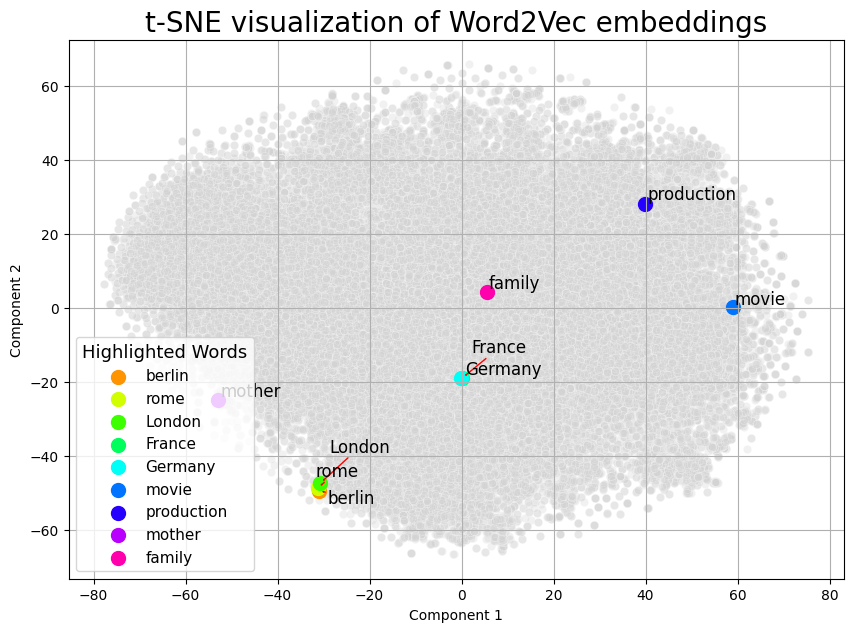

In [10]:
# Apply t-SNE to the entire set of vectors
tsne = TSNE(n_components=2, random_state=0)
Y_tsne = tsne.fit_transform(all_vectors)

highlight_words = ['berlin', 'rome', 'London', 'France', 'Germany',
                    'movie', 'production', 'mother', 'family']

highs = [w.lower() for w in highlight_words]
indices = [all_words.index(word) for word in highs if word in all_words]
highlight_vectors = np.array([all_vectors[index] for index in indices])
Y_highlight = Y_tsne[indices]


plt.figure(figsize=(10, 7))


sns.scatterplot(x=Y_tsne[:, 0], y=Y_tsne[:, 1], color="lightgrey", alpha=0.3)

# Plot highlighted words 
palette = sns.color_palette("hsv", len(highlight_words))
texts = []
for i, word in enumerate(highlight_words):
    plt.scatter(Y_highlight[i, 0], Y_highlight[i, 1], color=palette[i], s=100, label=word)
    # adjust text
    texts.append(plt.text(Y_highlight[i, 0], Y_highlight[i, 1], word, fontsize=12))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('t-SNE visualization of Word2Vec embeddings', fontsize=20)
plt.xlabel('Component 1')
plt.ylabel('Component 2')


plt.grid(True)
plt.legend(title='Highlighted Words', title_fontsize='13', fontsize='11')
plt.savefig('word_tsne.jpg', format='jpeg')
plt.show()

In [11]:
# Apply UMAP to the entire set of vectors
umap = UMAP(n_components=2, random_state=42)  
Y_umap = umap.fit_transform(all_vectors)

Y_highlight = Y_umap[indices]


plt.figure(figsize=(10, 7))
sns.scatterplot(x=Y_umap[:, 0], y=Y_umap[:, 1], color="lightgrey", alpha=0.3)

palette = sns.color_palette("hsv", len(highlight_words))
texts = []
for i, word in enumerate(highlight_words):
    plt.scatter(Y_highlight[i, 0], Y_highlight[i, 1], color=palette[i], s=100, label=word)

    texts.append(plt.text(Y_highlight[i, 0], Y_highlight[i, 1], word, fontsize=12))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('UMAP visualization of Word2Vec embeddings', fontsize=20)
plt.xlabel('Component 1')
plt.ylabel('Component 2')


plt.grid(True)
plt.legend(title='Highlighted Words', title_fontsize='13', fontsize='11')
plt.savefig('word_umap.jpg', format='jpeg')
plt.show()

NameError: name 'UMAP' is not defined

C:\Users\dorot\AppData\Local\Temp\ipykernel_343380\1844515411.py:19: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(v1, v2) < 0:


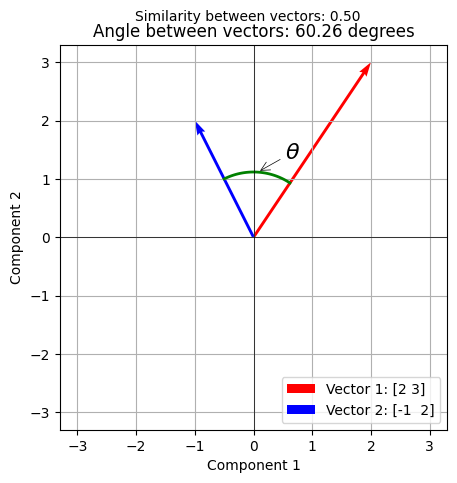

In [12]:
def plot_vectors_and_angle(v1, v2):
    
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    cosine_similarity = dot_product / (norm_v1 * norm_v2)
    angle_radians = np.arccos(cosine_similarity)
    angle_degrees = np.degrees(angle_radians)

   
    fig, ax = plt.subplots(figsize=(5, 5))
    
  
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label=f"Vector 1: {v1}")
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label=f"Vector 2: {v2}")

   
    start_angle = np.arctan2(v1[1], v1[0])
    if np.cross(v1, v2) < 0:
        angle_radians = -angle_radians

  
    theta = np.linspace(start_angle, start_angle + angle_radians, 100)
    r = 0.5 * min(np.linalg.norm(v1), np.linalg.norm(v2))  
    x = r * np.cos(theta)
    y = r * np.sin(theta)

   
    ax.plot(x, y, linestyle='-', color='green', lw=2)

    
    midpoint = (start_angle + angle_radians / 2)
    ax.annotate(r'$\theta$', xy=(r * np.cos(midpoint), r * np.sin(midpoint)), xytext=(20, 10), 
                textcoords='offset points', fontsize=16, arrowprops=dict(arrowstyle='->', lw=0.5))

    
    max_range = np.max(np.abs(np.vstack([v1, v2, [x.max(), y.max()]]))) * 1.1  # 10% padding
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])

   
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(f'Angle between vectors: {angle_degrees:.2f} degrees')
    plt.suptitle(f'Similarity between vectors: {cosine_similarity:.2f}', fontsize=10, y=.95)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend(loc='lower right')
    plt.savefig('cosine_similarity.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

    return cosine_similarity, angle_degrees

# Example usage
v1 = np.array([2, 3])
v2 = np.array([-1, 2])
cos_sim, angle = plot_vectors_and_angle(v1, v2)

In [13]:

word_1 = "good"
syn = "great"
ant = "bad"
most_sim =model.wv.most_similar("good")
print("Top 3 most simalr words to {} are :{}".format(word_1, most_sim[:3]))

synonyms_dist = model.wv.distance(word_1, syn)
antonyms_dist = model.wv.distance(word_1, ant)
print("Synonyms {}, {} have cosine distance: {}".format(word_1, syn, synonyms_dist))
print("Antonyms {}, {} have cosine distance: {}".format(word_1, ant, antonyms_dist))
a = 'king'
a_star = 'man'
b = 'woman'
b_star= model.wv.most_similar(positive=[a, b], negative=[a_star])
print("{} is to {} as {} is to: {} ".format(a, a_star, b, b_star[0][0]))

Top 3 most simalr words to good are :[('decent', 0.792752742767334), ('great', 0.777266800403595), ('bad', 0.7724612951278687)]
Synonyms good, great have cosine distance: 0.22273308038711548
Antonyms good, bad have cosine distance: 0.22753864526748657
king is to man as woman is to: queen 


## RNN, LSTM, GRU AND CCN FOR TEXT


In [14]:
import numpy as np
import torch
import torch.nn as nn

In [15]:

array = np.random.random((10, 5, 3))

data_tensor = torch.tensor(array, dtype=torch.float32)
RNN = nn.RNN(input_size=3, hidden_size=10,
                          num_layers=1, batch_first=True)
output, hidden = RNN(data_tensor)
output.shape

torch.Size([10, 5, 10])

In [16]:

data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)
LSTM =nn.LSTM(input_size=3, hidden_size=10,
                    num_layers=1, batch_first=True)
output, (hidden, cell) = LSTM(data_tensor)
output.shape

torch.Size([10, 5, 10])

In [17]:

data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)
GRU =nn.GRU(input_size=3, hidden_size=10,
                    num_layers=1, batch_first=True)
output, hidden = GRU(data_tensor)
output.shape

torch.Size([10, 5, 10])

In [18]:
data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)
Conv1d = nn.Conv1d(in_channels=5, out_channels=16, kernel_size=3, stride=1, padding=1)
output = Conv1d(data_tensor)
output.shape

torch.Size([10, 16, 3])

## Classify review with DL

In [20]:
!pip install wordcloud

In [21]:
import numpy as np 
import pandas as pd 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize
from collections import Counter
import string
import re
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import sys
import os
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from wordcloud import WordCloud

is_cuda = torch.cuda.is_available()

# Check if we GPU available
if is_cuda:
    device = torch.device("cuda")
    print("Using GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dorot\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dorot\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Using GPU


In [22]:
try:
    df=pd.read_csv("IMDB Dataset.csv")
except:
    !wget https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true
    !unzip IMDB.zip?raw=true

df['sentiment_encoded'] = np.where(df['sentiment']=='positive',0,1)
X,y = df['review'].values, df['sentiment_encoded'].values
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y, test_size=.2)
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,stratify=y_train, test_size=.1)
y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(y_test)

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


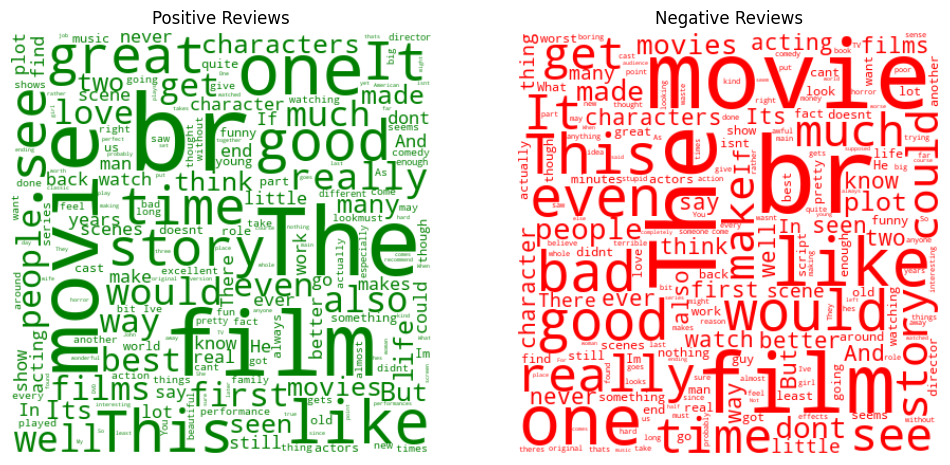

In [23]:
def generate_wordclouds(df):
    '''
    Generate two word clouds from the 50 most frequent words in the list of positive and negative reviews respectively.
    
    '''
    stop_words = set(stopwords.words('english'))  
    
    # Separating reviews by sentiment
    positive_reviews = df[df['sentiment'] == 'positive']['review']
    negative_reviews = df[df['sentiment'] == 'negative']['review']
    
    
    def get_words(reviews):
        all_words = []
        for review in reviews:
            review = re.sub(r"[^\w\s]", '', review)
            review = re.sub(r"\d", '', review)
            words = review.split()
            filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
            all_words.extend(filtered_words)
        return all_words

    
    positive_words = get_words(positive_reviews)
    negative_words = get_words(negative_reviews)
    
   
    positive_counts = Counter(positive_words)
    negative_counts = Counter(negative_words)
    
    
    positive_wordcloud = WordCloud(
        width=400,
        height=400,
        max_words=200,
        max_font_size=100,
        background_color='white',
        color_func=lambda *args, **kwargs: "green"  
    ).generate_from_frequencies(positive_counts)
    
    negative_wordcloud = WordCloud(
        width=400,
        height=400,
        max_words=200,
        max_font_size=100,
        background_color='white',
        color_func=lambda *args, **kwargs: "red"  
    ).generate_from_frequencies(negative_counts)
    
   
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(positive_wordcloud, interpolation='bilinear')
    plt.title('Positive Reviews')
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(negative_wordcloud, interpolation='bilinear')
    plt.title('Negative Reviews')
    plt.axis("off")
    plt.savefig('word_clouds.jpg', format='jpeg', bbox_inches='tight')
    plt.show()
    
generate_wordclouds(df)

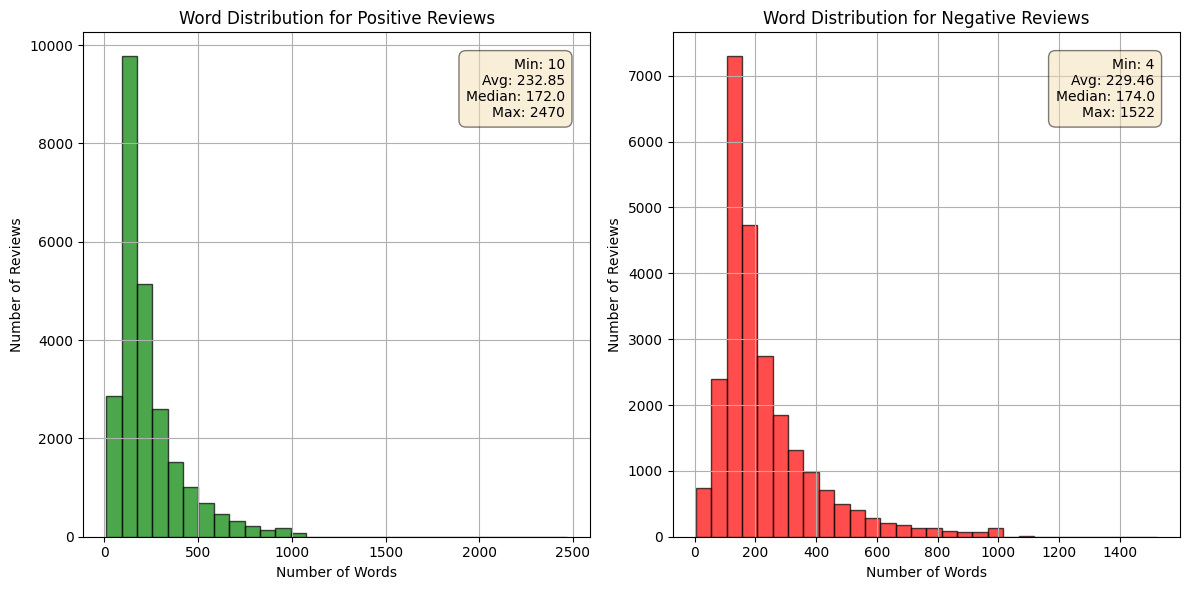

In [24]:
def plot_review_length_by_sentiment(df):
    '''
    Plots histograms of the number of words per review for positive and negative reviews with summary statistics.
    
    '''
   
    positive_reviews = df[df['sentiment'] == 'positive']['review']
    negative_reviews = df[df['sentiment'] == 'negative']['review']
    
    
    def get_review_lengths(reviews):
        return [len(review.split()) for review in reviews]

    
    positive_lengths = get_review_lengths(positive_reviews)
    negative_lengths = get_review_lengths(negative_reviews)

    
    def get_summary_stats(lengths):
        return {
            'min': np.min(lengths),
            'avg': np.mean(lengths),
            'median': np.median(lengths),
            'max': np.max(lengths)
        }

    pos_stats = get_summary_stats(positive_lengths)
    neg_stats = get_summary_stats(negative_lengths)

   
    plt.figure(figsize=(12, 6))

    # Plot for positive reviews
    plt.subplot(1, 2, 1)
    plt.hist(positive_lengths, bins=30, color='green', edgecolor='black', alpha=0.7)
    plt.title('Word Distribution for Positive Reviews')
    plt.xlabel('Number of Words')
    plt.ylabel('Number of Reviews')
    plt.grid(True)
    stats_text = f"Min: {pos_stats['min']}\nAvg: {pos_stats['avg']:.2f}\nMedian: {pos_stats['median']}\nMax: {pos_stats['max']}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))

    # Plot for negative reviews
    plt.subplot(1, 2, 2)
    plt.hist(negative_lengths, bins=30, color='red', edgecolor='black', alpha=0.7)
    plt.title('Word Distribution for Negative Reviews')
    plt.xlabel('Number of Words')
    plt.ylabel('Number of Reviews')
    plt.grid(True)
    stats_text = f"Min: {neg_stats['min']}\nAvg: {neg_stats['avg']:.2f}\nMedian: {neg_stats['median']}\nMax: {neg_stats['max']}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig('review_length.jpg', format='jpeg', bbox_inches='tight')
    plt.show()
    
plot_review_length_by_sentiment(df)

In [25]:
def preprocess_review(review):
    '''
    Cleaning of the review: remove non-alphanumeric characters, collapse whitespace, and remove digits.
    '''
    review = re.sub(r"[^\w\s]", ' ', review)  # Replace non-word characters with space
    review = re.sub(r"\s+", ' ', review)      # Replace multiple spaces with a single space
    review = re.sub(r"\d", '', review)        # Remove digits
    return review.strip().lower()

def tokenize_reviews(x_train, x_val, x_test):
    stop_words = set(stopwords.words('english'))
    
    # tokenize and clean list of reviews
    def tokenize_and_filter(reviews):
        word_list = []
        for review in reviews:
            words = word_tokenize(preprocess_review(review))
            filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
            word_list.extend(filtered_words)
        return word_list

    # Create a corpus 
    corpus = Counter(tokenize_and_filter(x_train))
    # Select the 1000 most common words 
    vocab = {word: i+1 for i, word in enumerate([word for word, freq in corpus.most_common(1000)])}

    # convert reviews into sequences of indices
    def vectorize_reviews(reviews):
        vectorized = []
        for review in reviews:
            tokenized = word_tokenize(preprocess_review(review))
            indexed = [vocab[word] for word in tokenized if word in vocab]
            vectorized.append(indexed)
        return vectorized

    _x_train = vectorize_reviews(x_train)
    _x_val = vectorize_reviews(x_val)
    _x_test = vectorize_reviews(x_test)

    return _x_train, _x_val, _x_test, vocab


x_train, x_val, x_test, vocab = tokenize_reviews(x_train, x_val, x_test)

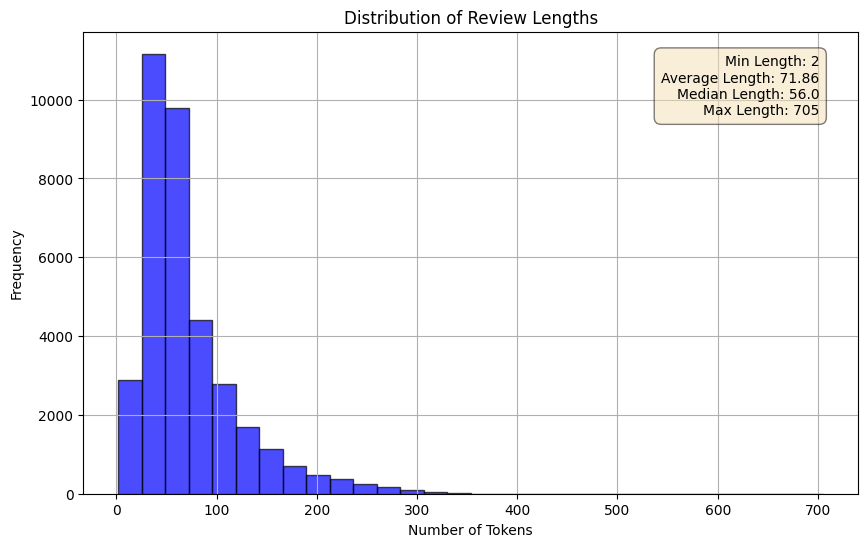

In [26]:
def plot_review_length_distribution(tokenized_reviews):
    '''
    Plots a histogram of the lengths of tokenized reviews and includes a box with summary statistics.
    
    '''
    
    review_lengths = [len(review) for review in tokenized_reviews]
    
    # Calculate summary statistics
    min_length = np.min(review_lengths)
    avg_length = np.mean(review_lengths)
    median_length = np.median(review_lengths)
    max_length = np.max(review_lengths)
    
    
    plt.figure(figsize=(10, 6))
    plt.hist(review_lengths, bins=30, color='blue', edgecolor='black', alpha=0.7)
    plt.title('Distribution of Review Lengths')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Frequency')
    plt.grid(True)

    
    stats_text = f'Min Length: {min_length}\nAverage Length: {avg_length:.2f}\nMedian Length: {median_length}\nMax Length: {max_length}'
    plt.gca().text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))
    plt.savefig('review_length_after_tokenization.jpg', format='jpeg', bbox_inches='tight')
    plt.show()
    
plot_review_length_distribution(x_train)

In [27]:
def padding_(reviews, max_seq):
    features = np.zeros((len(reviews), max_seq),dtype=int)
    for ii, review in enumerate(reviews):
        if len(review) != 0:
            features[ii, -len(review):] = np.array(review)[:max_seq]
    return np.array(features)

train_data = TensorDataset(torch.from_numpy(padding_(x_train,500)), torch.from_numpy(y_train))
valid_data = TensorDataset(torch.from_numpy(padding_(x_val,500)), torch.from_numpy(y_val))
test_data = TensorDataset(torch.from_numpy(padding_(x_test,500)), torch.from_numpy(y_test))

train_loader = DataLoader(train_data, shuffle=True, batch_size=50)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=50)
test_loader = DataLoader(test_data, shuffle=True, batch_size=50)

In [28]:
class SentimentRNN(nn.Module):
    def __init__(self, no_layers, vocab_size, hidden_dim, embedding_dim, drop_prob=0.5):
        super(SentimentRNN, self).__init__()
 
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.no_layers = no_layers
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.GRU(input_size=embedding_dim, hidden_size=self.hidden_dim,
                          num_layers=no_layers, batch_first=True)
        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(self.hidden_dim, output_dim)
        self.sig = nn.Sigmoid()
        
    def forward(self, x, hidden):
        batch_size = x.size(0)
        embeds = self.embedding(x)  
        rnn_out, hidden = self.rnn(embeds, hidden)
        rnn_out = rnn_out.contiguous().view(-1, self.hidden_dim)
        out = self.dropout(rnn_out)
        sig_out = self.sig(out)
        sig_out = sig_out.view(batch_size, -1)
        sig_out = sig_out[:, -1]  
        return sig_out, hidden
        
    def init_hidden(self, batch_size):
        ''' Initializes hidden state '''
        
        h0 = torch.zeros((self.no_layers, batch_size, self.hidden_dim)).to(device)
        return h0

# Hyperparameters
no_layers = 3
vocab_size = len(vocab) + 1  
embedding_dim = 300
output_dim = 1
hidden_dim = 256

# Initialize the model
model = SentimentRNN(no_layers, vocab_size, hidden_dim, embedding_dim, drop_prob=0.5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)

SentimentRNN(
  (embedding): Embedding(1001, 300)
  (rnn): GRU(300, 256, num_layers=3, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)


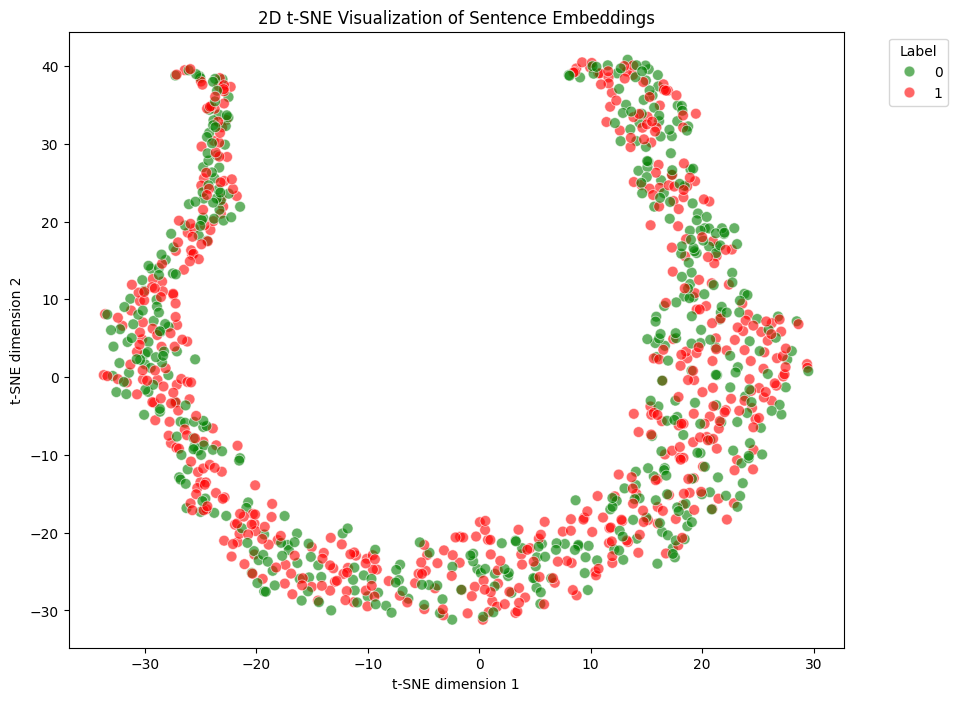

In [29]:
x_train_tsne = padding_(x_train,500)
x_train_tsne = x_train_tsne[:1000,:]
y_train_tsne= y_train[:1000]

def plot_embeddings(x_train, y_train, model, device, batch_size=50):
    model.eval()  
    embeddings_list = []

    # Create a DataLoader to handle the x_train data in batches
    train_dataset = torch.utils.data.TensorDataset(torch.from_numpy(x_train), 
                               torch.from_numpy(y_train))
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():  # No need to track gradients
        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)
            hidden = model.init_hidden(x_batch.size(0))
            
            # Feed forward through the model to get to the embeddings layer
            embeds = model.embedding(x_batch)
            rnn_out, hidden = model.rnn(embeds, hidden)
            rnn_out = rnn_out.contiguous().view(-1, model.hidden_dim)  # Flatten the output
            out = model.dropout(rnn_out)
            linear_output = model.fc(out)  
            
            embeddings_list.append(linear_output.cpu())  # Store CPU data

    # Concatenate all batch embeddings into a single matrix
    all_embeddings = torch.cat(embeddings_list, dim=0)

    all_embeddings = all_embeddings.view(-1, 500)  

    # Reduce dimensions to 2D using t-SNE for visualization
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(all_embeddings.numpy()) 

    df = pd.DataFrame(data=embeddings_2d, columns=['TSNE-1', 'TSNE-2'])
    df['label'] = y_train  
    custom_palette = {0: 'green', 1: 'red'}

    plt.figure(figsize=(10, 8))
    scatter = sns.scatterplot(data=df, x='TSNE-1', y='TSNE-2', hue='label', palette=custom_palette , s=60, alpha=0.6)
    plt.title('2D t-SNE Visualization of Sentence Embeddings')
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc=2)  
    plt.savefig('tsne_model_untrained_projection.jpg', format='jpeg', bbox_inches='tight')
    plt.show()


plot_embeddings(x_train_tsne, y_train_tsne, model, device, batch_size=50)

In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


lr = 0.001

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

def acc(pred, label):
    """Calculate accuracy by comparing predicted labels with true labels."""
    pred = torch.round(pred.squeeze())
    return torch.sum(pred == label.squeeze()).item()

clip = 5
epochs = 5
valid_loss_min = np.inf  


epoch_tr_loss, epoch_vl_loss = [], []
epoch_tr_acc, epoch_vl_acc = [], []


for epoch in range(epochs):
    train_losses = []
    train_acc = 0.0
    model.train()  # Set model to training mode

    # Initialize hidden state
    h = model.init_hidden(50)
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Detach hidden states
        h = h.data
        
        model.zero_grad()
        output, h = model(inputs, h)
        
        # Calculate the loss
        loss = criterion(output.squeeze(), labels.float())
        loss.backward()
        train_losses.append(loss.item())

        # Calculate accuracy
        accuracy = acc(output, labels)
        train_acc += accuracy

        # Clip gradients to prevent exploding gradient issues in RNNs
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
    
    # Validation phase
    val_losses = []
    val_acc = 0.0
    model.eval()  # Set model to evaluation mode
    val_h = model.init_hidden(50)

    for inputs, labels in valid_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Detach hidden states
        val_h = val_h.data

        output, val_h = model(inputs, val_h)
        val_loss = criterion(output.squeeze(), labels.float())

        val_losses.append(val_loss.item())

        accuracy = acc(output, labels)
        val_acc += accuracy

    epoch_train_loss = np.mean(train_losses)
    epoch_val_loss = np.mean(val_losses)
    epoch_train_acc = train_acc / len(train_loader.dataset)
    epoch_val_acc = val_acc / len(valid_loader.dataset)

    epoch_tr_loss.append(epoch_train_loss)
    epoch_vl_loss.append(epoch_val_loss)
    epoch_tr_acc.append(epoch_train_acc)
    epoch_vl_acc.append(epoch_val_acc)

    print(f'Epoch {epoch+1}')
    print(f'Train Loss: {epoch_train_loss} Val Loss: {epoch_val_loss}')
    print(f'Train Accuracy: {epoch_train_acc * 100}% Val Accuracy: {epoch_val_acc * 100}%')
    print(' ')

Epoch 1
Train Loss: 0.5795663855969906 Val Loss: 0.47358044497668744
Train Accuracy: 64.23333333333333% Val Accuracy: 83.675%
 
Epoch 2
Train Loss: 0.5328464961300293 Val Loss: 0.4661832697689533
Train Accuracy: 67.35833333333333% Val Accuracy: 84.1%
 
Epoch 3
Train Loss: 0.5199991799890995 Val Loss: 0.46357627101242543
Train Accuracy: 68.16388888888889% Val Accuracy: 84.625%
 
Epoch 4
Train Loss: 0.5080343982825677 Val Loss: 0.4534515496343374
Train Accuracy: 69.15277777777777% Val Accuracy: 85.39999999999999%
 
Epoch 5
Train Loss: 0.4960314378970199 Val Loss: 0.45490510351955893
Train Accuracy: 69.79166666666666% Val Accuracy: 85.65%
 


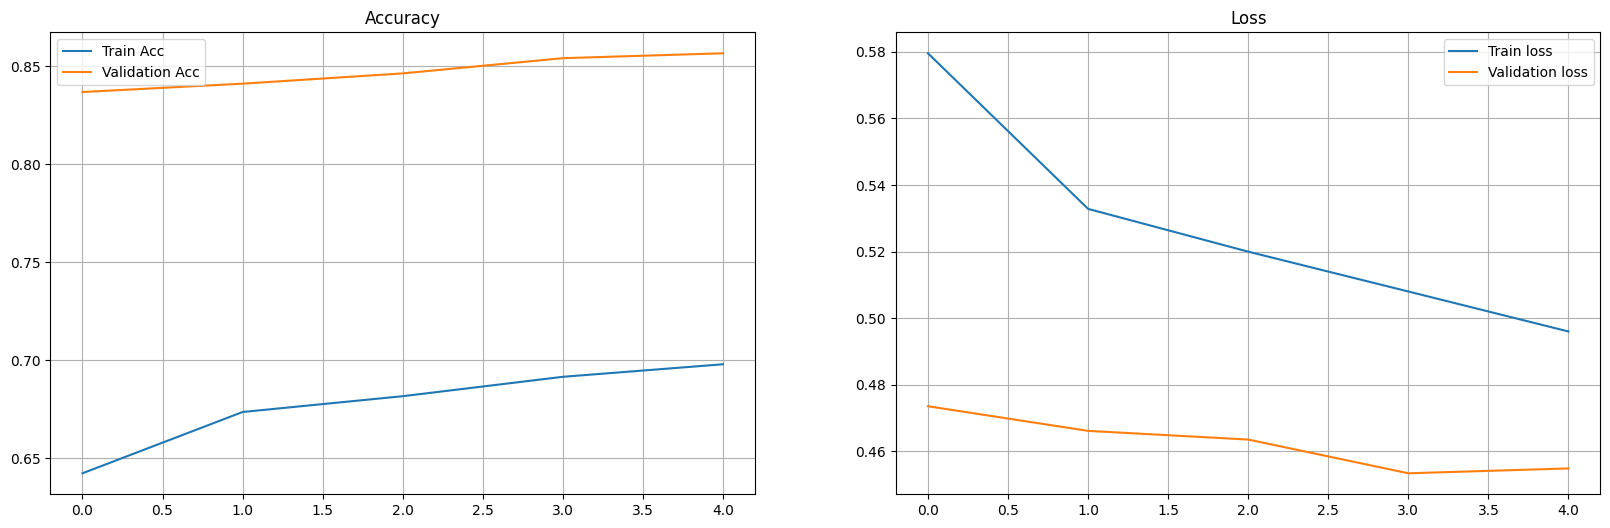

In [31]:

fig = plt.figure(figsize = (20, 6))
plt.subplot(1, 2, 1)
plt.plot(epoch_tr_acc, label='Train Acc')
plt.plot(epoch_vl_acc, label='Validation Acc')
plt.title("Accuracy")
plt.legend()
plt.grid()
    
plt.subplot(1, 2, 2)
plt.plot(epoch_tr_loss, label='Train loss')
plt.plot(epoch_vl_loss, label='Validation loss')
plt.title("Loss")
plt.legend()
plt.grid()
plt.savefig('accuracy_and_loss.jpg', format='jpeg', bbox_inches='tight')
plt.show()

Accuracy on test set: 0.8489


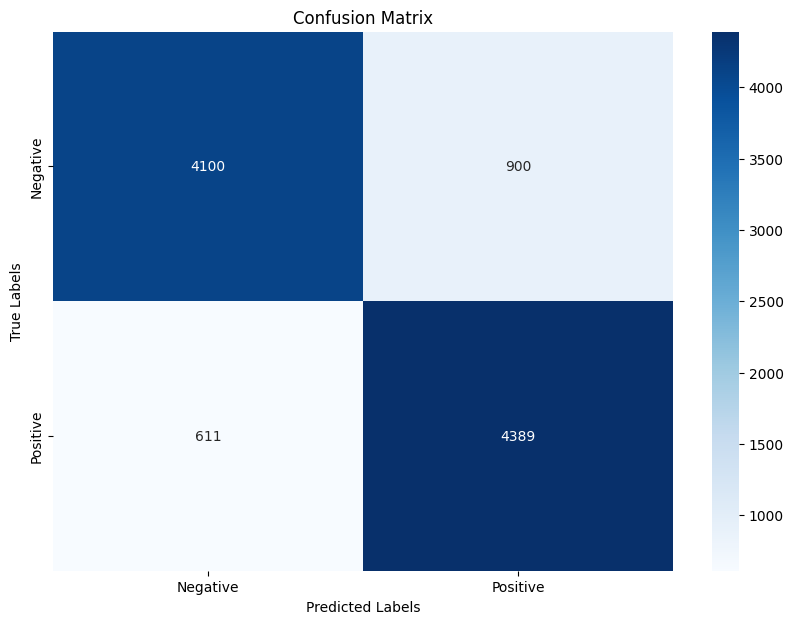

In [32]:
def predict_batch(model, data_loader, device):
    """Predict output for a batch of data using the RNN model."""
    model.eval()  
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            batch_size = inputs.size(0)
            
            hidden = model.init_hidden(batch_size).to(device)

            output, _ = model(inputs, hidden)
            
            predicted_probs = torch.sigmoid(output)
            predicted_labels = (predicted_probs > 0.60).float() 
            
            predictions.extend(predicted_labels.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels, predicted_probs, labels


predictions, true_labels, predicted_probs, labels = predict_batch(model, test_loader, device)
print(f'Accuracy on test set: {accuracy_score(true_labels, predictions)}')
# Plot confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.jpg', format='jpeg', bbox_inches='tight')
plt.show()

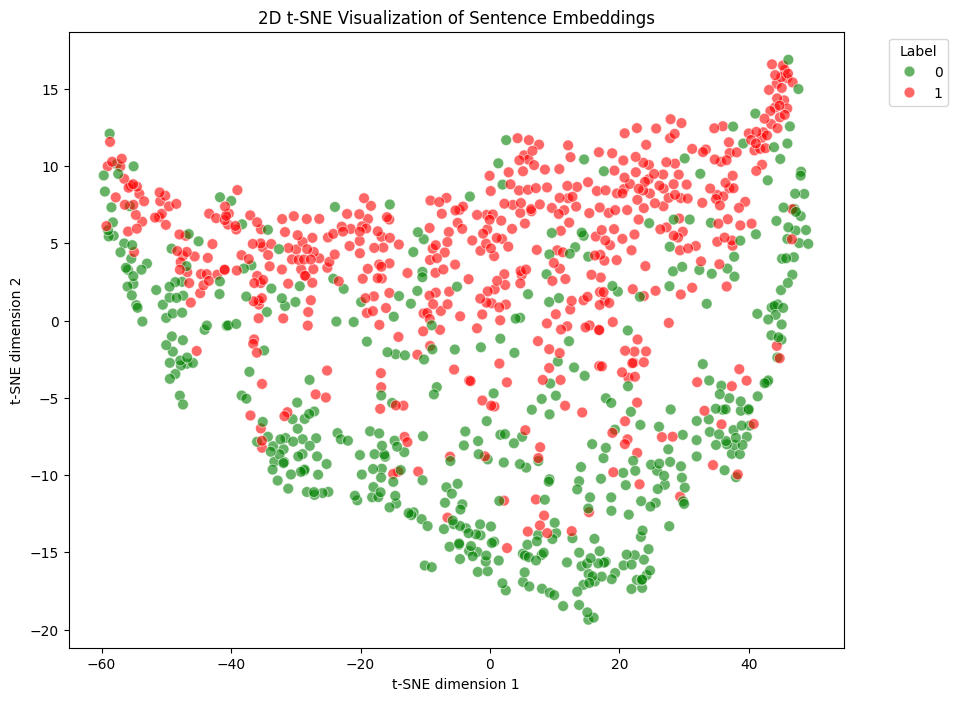

In [33]:
plot_embeddings(x_train_tsne, y_train_tsne, model, device, batch_size=50)